# Sensitivity / FDR vs. localization jitter

Interactive notebook version of `workflow/scripts/plot_sens_fdr_vs_density.py`.

The pipeline script is driven by Snakemake (`snakemake.input`/`snakemake.wildcards`/`snakemake.output`); this notebook does the same plotting from a `results/all_methods_{code}.csv` file you point it at directly, so you can explore the figure without running the workflow.

Edit the **Parameters** cell below, then run all cells.

In [1]:
# Parameters
# `code` identifies which simulated codebook's results to plot (matches config/codes_to_simulate.csv).
code = "seqFISHp2019"

# Aggregated scores produced by rule aggregate_all_for_code.
input_csv = f"../../results/all_methods_{code}.csv"

# Set to a path (e.g. f"../../results/plots/sens_fdr_vs_density_{code}.png") to also write files
# to disk, matching rule plot_sens_fdr's outputs. Leave as None to only display inline.
output_png = None
output_pdf = None

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
plt.rcParams['svg.fonttype'] = 'none'

mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['font.size'] = 7
mpl.rcParams['axes.titlesize'] = 7
mpl.rcParams['axes.labelsize'] = 7
mpl.rcParams['xtick.labelsize'] = 7
mpl.rcParams['ytick.labelsize'] = 7
mpl.rcParams['legend.fontsize'] = 7
mpl.rcParams['legend.title_fontsize'] = 7
mpl.rcParams['figure.titlesize'] = 7

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
plt.rcParams['svg.fonttype'] = 'none'

%matplotlib inline

## Comparison across all three codes

Reads the three `all_methods_*` result CSVs sitting in this notebook's folder and plots Sensitivity in one row (one panel per codebook), with a single shared legend for methods and conditions across codes.

In [3]:
# Parameters
# Maps a display label -> results CSV (relative to this notebook's folder).
# These are the three codebooks' aggregated results currently sitting in this folder.
csv_files = {
    "Hamming_q2_n16_k11_w4cb_MERFISH_2015": "all_methods_Hamming_q2_n16_k11_w4cb_MERFISH_2015.csv",
    "seqFISHp2019": "all_methods_seqFISHp2019.csv",
    "RSq11_n10_k7_271cws": "all_methods_q11_n10_k7_w4cb_pool1.csv",
}

# Set to a path (e.g. "../../results/plots/sens_fdr_vs_density_all_codes.png") to also write
# a file to disk. Leave as None to only display inline.
all_codes_output_png = None
all_codes_output_pdf = None

In [4]:
data_by_code = {}
for label, fname in csv_files.items():
    df = pd.read_csv(fname)
    print(df.head())
    df = df.dropna(subset=["method"])
    data_by_code[label] = df

data_by_code[next(iter(data_by_code))].head()

     method                                  code  nbarcodes  rstdv  rep  \
0  bardensr  Hamming_q2_n16_k11_w4cb_MERFISH_2015          5   0.00    1   
1  bardensr  Hamming_q2_n16_k11_w4cb_MERFISH_2015          5   0.25    1   
2  bardensr  Hamming_q2_n16_k11_w4cb_MERFISH_2015          5   0.50    1   
3  bardensr  Hamming_q2_n16_k11_w4cb_MERFISH_2015          5   0.75    1   
4  bardensr  Hamming_q2_n16_k11_w4cb_MERFISH_2015          5   1.00    1   

   sensitivity  fdr  n_true  n_decoded  n_fd  not_decoded_true  param_l1  \
0          1.0  0.0       5          5   0.0               0.0     0.000   
1          0.4  0.0       5          2   0.0               3.0     0.001   
2          0.8  0.0       5          4   0.0               1.0     0.000   
3          0.2  0.0       5          1   0.0               4.0     0.000   
4          0.6  0.0       5          3   0.0               2.0     0.010   

   param_peak  param_Q  param_tau  best_lambda  
0        0.35      NaN        NaN    

,method,code,nbarcodes,rstdv,rep,sensitivity,fdr,n_true,n_decoded,n_fd,not_decoded_true,param_l1,param_peak,param_Q,param_tau,best_lambda
0,bardensr,Hamming_q2_n16_k11_w4cb_MERFISH_2015,5,0.00,1,1.0,0.0,5,5,0.0,0.0,0.000,0.35,NaN,NaN,NaN
1,bardensr,Hamming_q2_n16_k11_w4cb_MERFISH_2015,5,0.25,1,0.4,0.0,5,2,0.0,3.0,0.001,0.25,NaN,NaN,NaN
2,bardensr,Hamming_q2_n16_k11_w4cb_MERFISH_2015,5,0.50,1,0.8,0.0,5,4,0.0,1.0,0.000,0.20,NaN,NaN,NaN
3,bardensr,Hamming_q2_n16_k11_w4cb_MERFISH_2015,5,0.75,1,0.2,0.0,5,1,0.0,4.0,0.000,0.50,NaN,NaN,NaN
4,bardensr,Hamming_q2_n16_k11_w4cb_MERFISH_2015,5,1.00,1,0.6,0.0,5,3,0.0,2.0,0.010,0.60,NaN,NaN,NaN


In [5]:
#methods = sorted(data["method"].unique())
#densities = sorted(data["nbarcodes"].unique())

#colors = plt.cm.tab10(np.linspace(0, 1, max(len(methods), 10)))
#method_colors = {m: colors[i] for i, m in enumerate(methods)}

markers = ["o", "s", "^", "D", "v", "P", "X", "*"]
linestyles = ["-", "--", "-.", ":", "-", "--", "-.", ":"]
#density_markers = {d: markers[i % len(markers)] for i, d in enumerate(densities)}
#density_linestyles = {d: linestyles[i % len(linestyles)] for i, d in enumerate(densities)}

sweep_col = "rstdv"
sweep_label = "Localization jitter SD (pixels)"

#methods, densities

In [6]:
# Union across all codes so a given method/density gets the same color/marker in every row.
all_methods = sorted(set().union(*(set(df["method"].unique()) for df in data_by_code.values())))
all_densities = sorted(set().union(*(set(df["nbarcodes"].unique()) for df in data_by_code.values())))

all_colors = plt.cm.tab10(np.linspace(0, 1, max(len(all_methods), 10)))
all_method_colors = {m: all_colors[i] for i, m in enumerate(all_methods)}

all_density_markers = {d: markers[i % len(markers)] for i, d in enumerate(all_densities)}
all_density_linestyles = {d: linestyles[i % len(linestyles)] for i, d in enumerate(all_densities)}

all_methods, all_densities

(['Untangle: CS l0',
  'Untangle: spots first',
  'bardensr',
  'graph_iss',
  'istdeco'],
 [np.int64(5),
  np.int64(10),
  np.int64(15),
  np.int64(20),
  np.int64(25),
  np.int64(30)])

## Seaborn version

Same sensitivity-vs-jitter comparison across all three codes, built with `seaborn.relplot` instead of manual `errorbar` calls. Faceting on `code_label` gives the one-row-per-code layout, and mapping `method` to `hue` and `density` to `style` makes seaborn build a legend with separate titled sections for color (method) and line/marker style (density) automatically — no manual proxy-handle bookkeeping needed.

In [7]:
rename_legend_handles = {
    "method": "Method",
    "Untangle: CS l0": "Untangle:\ncompressed sensing",
    "Untangle: spots first": "Untangle: spots-first",
    "bardensr": "BarDenSR",
    "graph_iss": "Graph-ISS",
    "istdeco": "ISTDECO",
    "density": "# of barcodes in ROI"
}

['method', 'Untangle: CS l0', 'Untangle: spots first', 'bardensr', 'graph_iss', 'istdeco', 'density', '5', '10', '15', '20', '25', '30']
[<matplotlib.lines.Line2D object at 0x0000016B4434CCD0>, <matplotlib.lines.Line2D object at 0x0000016B4434D310>, <matplotlib.lines.Line2D object at 0x0000016B4434D810>, <matplotlib.lines.Line2D object at 0x0000016B4434DD10>, <matplotlib.lines.Line2D object at 0x0000016B4434E210>, <matplotlib.lines.Line2D object at 0x0000016B4434E710>, <matplotlib.lines.Line2D object at 0x0000016B4434EC10>, <matplotlib.lines.Line2D object at 0x0000016B4434F110>, <matplotlib.lines.Line2D object at 0x0000016B4434F610>, <matplotlib.lines.Line2D object at 0x0000016B4434FB10>, <matplotlib.lines.Line2D object at 0x0000016B413F4050>, <matplotlib.lines.Line2D object at 0x0000016B413F4550>, <matplotlib.lines.Line2D object at 0x0000016B413F4A50>]


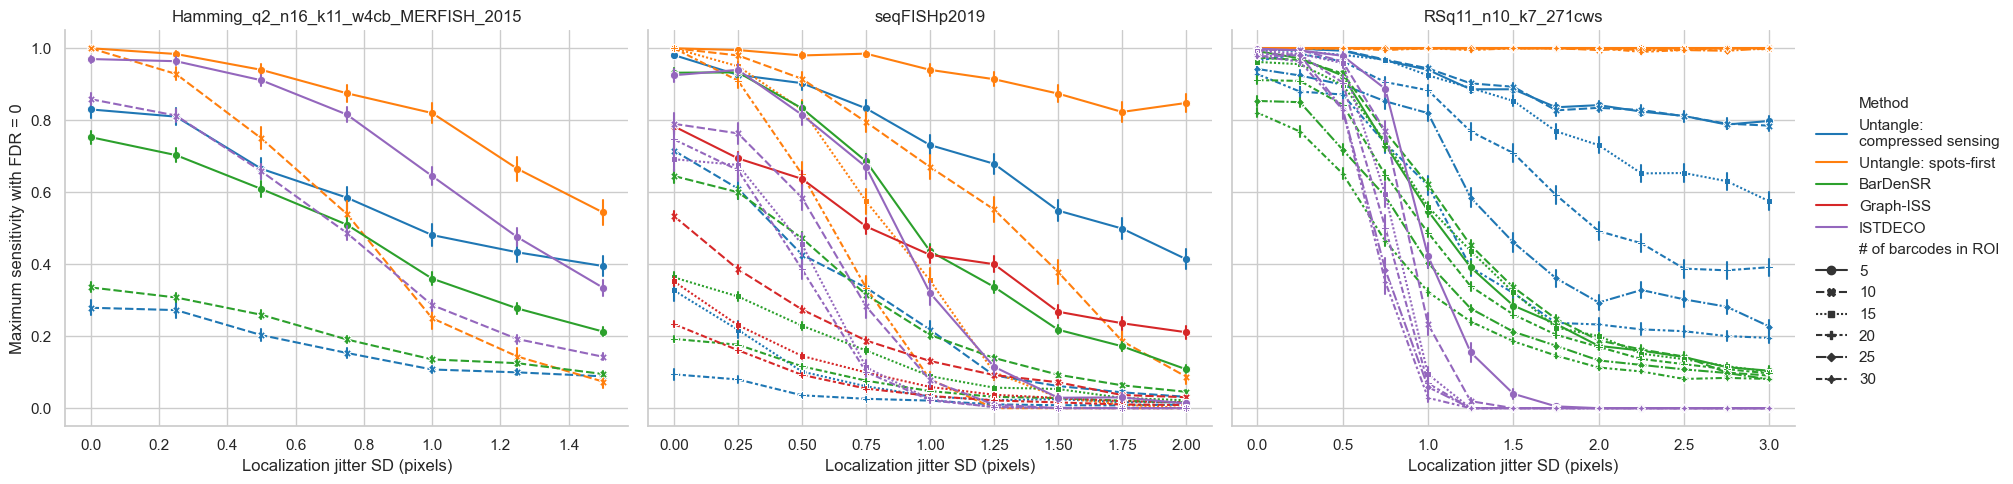

In [8]:
import seaborn as sns


combined = pd.concat(
    [df.assign(code_label=label) for label, df in data_by_code.items()],
    ignore_index=True
).rename(columns={"nbarcodes": "density"})

sns.set_theme(style="whitegrid")

g = sns.relplot(
    data=combined,
    x=sweep_col, y="sensitivity",
    hue="method", hue_order=all_methods, palette=all_method_colors,
    style="density", style_order=all_densities,
    col="code_label", col_order=list(data_by_code.keys()),
    kind="line", markers=True, dashes=True,
    errorbar="se", err_style="bars",
    facet_kws={"sharex": False},
    height=5, aspect=1.1,
)
g.set_axis_labels(sweep_label, "Maximum sensitivity with FDR = 0")
g.set_titles("{col_name}")

if all_codes_output_png:
    g.savefig(all_codes_output_png, dpi=150, bbox_inches="tight")
if all_codes_output_pdf:
    g.savefig(all_codes_output_pdf, bbox_inches="tight")

# seaborn inserts "method"/"density" as bold section-header rows inside the legend body
# (distinct from the legend's own .set_title()) whenever hue and style map to different
# variables. Drop just the "method" header row and rebuild the legend via add_legend() so
# seaborn redoes its own spacing/sizing, rather than editing the rendered Legend in place.
handles = g.legend.legend_handles
labels = [t.get_text() for t in g.legend.texts]
kept = [
    (rename_legend_handles.get(label, label), handle)
    for label, handle in zip(labels, handles)
]

print(labels)
print(handles)

g.legend.remove()
g.add_legend(legend_data=dict(kept), label_order=[label for label, _ in kept], title="")

plt.show()

In [9]:
combined

,method,code,density,rstdv,rep,sensitivity,fdr,n_true,n_decoded,n_fd,not_decoded_true,param_l1,param_peak,param_Q,param_tau,best_lambda,code_label,param_k1
0,bardensr,Hamming_q2_n16_k11_w4cb_MERFISH_2015,5,0.00,1,1.0,0.0,5,5,0.0,0.0,0.000,0.35,NaN,NaN,NaN,Hamming_q2_n16_k11_w4cb_MERFISH_2015,NaN
1,bardensr,Hamming_q2_n16_k11_w4cb_MERFISH_2015,5,0.25,1,0.4,0.0,5,2,0.0,3.0,0.001,0.25,NaN,NaN,NaN,Hamming_q2_n16_k11_w4cb_MERFISH_2015,NaN
2,bardensr,Hamming_q2_n16_k11_w4cb_MERFISH_2015,5,0.50,1,0.8,0.0,5,4,0.0,1.0,0.000,0.20,NaN,NaN,NaN,Hamming_q2_n16_k11_w4cb_MERFISH_2015,NaN
3,bardensr,Hamming_q2_n16_k11_w4cb_MERFISH_2015,5,0.75,1,0.2,0.0,5,1,0.0,4.0,0.000,0.50,NaN,NaN,NaN,Hamming_q2_n16_k11_w4cb_MERFISH_2015,NaN
4,bardensr,Hamming_q2_n16_k11_w4cb_MERFISH_2015,5,1.00,1,0.6,0.0,5,3,0.0,2.0,0.010,0.60,NaN,NaN,NaN,Hamming_q2_n16_k11_w4cb_MERFISH_2015,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109595,Untangle: spots first,q11_n10_k7_w4cb_pool1,30,2.00,200,1.0,0.0,30,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RSq11_n10_k7_271cws,NaN
109596,Untangle: spots first,q11_n10_k7_w4cb_pool1,30,2.25,200,1.0,0.0,30,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RSq11_n10_k7_271cws,NaN
109597,Untangle: spots first,q11_n10_k7_w4cb_pool1,30,2.50,200,1.0,0.0,30,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RSq11_n10_k7_271cws,NaN
109598,Untangle: spots first,q11_n10_k7_w4cb_pool1,30,2.75,200,1.0,0.0,30,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RSq11_n10_k7_271cws,NaN


['method', 'Untangle: CS l0', 'Untangle: spots first', 'bardensr', 'graph_iss', 'istdeco', 'density', '5', '10', '15', '20', '25', '30']
[<matplotlib.lines.Line2D object at 0x0000016B418DAC10>, <matplotlib.lines.Line2D object at 0x0000016B418DB110>, <matplotlib.lines.Line2D object at 0x0000016B418DB610>, <matplotlib.lines.Line2D object at 0x0000016B418DBB10>, <matplotlib.lines.Line2D object at 0x0000016B418AC050>, <matplotlib.lines.Line2D object at 0x0000016B418AC550>, <matplotlib.lines.Line2D object at 0x0000016B418ACA50>, <matplotlib.lines.Line2D object at 0x0000016B418ACF50>, <matplotlib.lines.Line2D object at 0x0000016B418AD450>, <matplotlib.lines.Line2D object at 0x0000016B418AD950>, <matplotlib.lines.Line2D object at 0x0000016B418ADE50>, <matplotlib.lines.Line2D object at 0x0000016B418AE350>, <matplotlib.lines.Line2D object at 0x0000016B418AE850>]


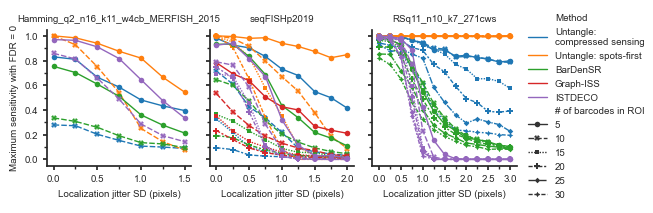

In [10]:
import seaborn as sns

combined = pd.concat(
    [df.assign(code_label=label) for label, df in data_by_code.items()],
    ignore_index=True
).rename(columns={"nbarcodes": "density"})

# sns.set_theme() resets rcParams to its own font/size defaults, so re-assert
# Arial/7pt via rc= here rather than relying on the mpl.rcParams set earlier.
sns.set_theme(style="ticks", rc={
    "font.family": "Arial",
    "font.size": 7,
    "axes.titlesize": 7,
    "axes.labelsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "legend.title_fontsize": 7,
    "lines.linewidth": 1,
    "lines.markersize": 4,
    # half of seaborn's notebook-context tick lengths (6 major / 4 minor).
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,
})

# height * aspect * ncols (3 code panels) = total figure width in inches.
n_cols = len(data_by_code)
target_width_in = 4.3
aspect = 0.7 #1.1
height = target_width_in / (n_cols * aspect)

g = sns.relplot(
    data=combined,
    x=sweep_col, y="sensitivity",
    hue="method", hue_order=all_methods, palette=all_method_colors,
    style="density", style_order=all_densities,
    col="code_label", col_order=list(data_by_code.keys()),
    kind="line", markers=True, dashes=True,
    # seaborn defaults markers to a white 0.75pt edge; drop it so the marker
    # sits flush on its line instead of punching a halo through it.
    markeredgewidth=0,
    errorbar=None,
    facet_kws={"sharex": False},
    height=height, aspect=aspect,
)
g.set_axis_labels(sweep_label, "Maximum sensitivity with FDR = 0")
g.set_titles("{col_name}")
#g.set(ylim=(0, 1))
g.axes.flat[0].set_yticks((0.1, 0.3, 0.5, 0.7, 0.9), minor=True)

# Per-panel x range, in col_order: each code was swept over a different jitter range.
#panel_xlims = [(0, 1.5), (0, 2.0), (0, 3.0)]
panel_major_xticks = [(0, 0.5, 1, 1.5),
                       (0, 0.5, 1, 1.5, 2),
                       (0, 0.5, 1, 1.5, 2, 2.5, 3)]
panel_minor_xticks = [(0.25, 0.75, 1.25),
                      (0.25, 0.75, 1.25, 1.75),
                      (0.25, 0.75, 1.25, 1.75, 2.25, 2.75)]

#for ax, xlim in zip(g.axes.flat, panel_xlims):
    #ax.set_xlim(xlim)
for i, ax in enumerate(g.axes.flat):
    #ax.set_xlim(panel_xlims[i])
    ax.set_xticks(panel_major_xticks[i])
    ax.set_xticks(panel_minor_xticks[i], minor = True)

if all_codes_output_png:
    g.savefig(all_codes_output_png, dpi=150, bbox_inches="tight")
if all_codes_output_pdf:
    g.savefig(all_codes_output_pdf, bbox_inches="tight")

# seaborn inserts "method"/"density" as bold section-header rows inside the legend body
# (distinct from the legend's own .set_title()) whenever hue and style map to different
# variables. Drop just the "method" header row and rebuild the legend via add_legend() so
# seaborn redoes its own spacing/sizing, rather than editing the rendered Legend in place.
handles = g.legend.legend_handles
labels = [t.get_text() for t in g.legend.texts]
kept = [
    (rename_legend_handles.get(label, label), handle)
    for label, handle in zip(labels, handles)
]

print(labels)
print(handles)

g.legend.remove()
g.add_legend(legend_data=dict(kept), label_order=[label for label, _ in kept], title="")

plt.savefig("benchmarking_sim.pdf")
